# Lab 7: Model Evaluation — การประเมินโมเดลจำแนกพืช PlantCLEF

| | |
|---|---|
| **วิชา** | 01076251 Machine Learning for Data Science |
| **หัวข้อ** | การประเมินประสิทธิภาพโมเดล (Model Evaluation) สำหรับการจำแนกพืชในแปลงสำรวจ |
| **ผู้จัดทำ** | ปิยังกูร ปัสสาวะกัง (6810405691) และ ศิวภูมิ พรหมจรรย์ (6810405887) |

---
## เป้าหมายของแลปนี้
1. **เปรียบเทียบกับโมเดลพื้นฐาน (Baseline Comparison)**: เทียบผลกับโมเดลเดาสุ่มและโมเดลเลือกกลุ่มที่เยอะที่สุด (Zero-Rule) เพื่อพิสูจน์ว่าโมเดลเรียนรู้ได้จริง
2. **รายงานผลรายกลุ่ม (Classification Report & Confusion Matrix)**: ดูความแม่นยำ Precision, Recall และ F1-Score ของแต่ละกลุ่มอย่างละเอียด
3. **ทดสอบความทนทานต่อสัญญาณรบกวน (Perturbation Test)**: ทดลองใส่สัญญาณรบกวน (Noise) ลงในภาพเพื่อดูว่าโมเดลยังตอบถูกหรือไม่
4. **วิเคราะห์ Overfitting และ Underfitting**: ดูว่าโมเดลจำข้อสอบเกินไปหรือไม่ และยังนำไปทายข้อมูลใหม่ได้ดีแค่ไหน
5. **ประเมินความพร้อมในการนำไปใช้งานจริง (Deployment Readiness)**: สรุปความพร้อมในการนำโมเดลไปติดตั้งใช้งานในแปลงสำรวจจริง

---
## 1. การโหลดข้อมูลและโมเดลที่บันทึกไว้

เราโหลดโมเดล `plantclef_provider_model.joblib` ที่ได้จากการพัฒนาใน Lab 5 พร้อมกับข้อมูลฟีเจอร์ DINOv2 และตารางข้อมูลเพื่อนำมาประเมินผล

In [1]:
import os
import sys
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

def resolve_file(fname):
    for p in [Path(fname), Path('mlsystem') / fname, Path('..') / fname]:
        if p.exists():
            return p
    return Path(fname)

train_feat_path = resolve_file('X_train_dinov2.npy')
val_feat_path   = resolve_file('X_val_dinov2.npy')
train_df_path   = resolve_file('i_train.parquet')
val_df_path     = resolve_file('i_val.parquet')
model_path      = resolve_file('plantclef_provider_model.joblib')

X_train = np.load(train_feat_path)
X_val   = np.load(val_feat_path)

X_train_norm = normalize(X_train, norm='l2')
X_val_norm   = normalize(X_val, norm='l2')

i_train = pd.read_parquet(train_df_path)
i_val   = pd.read_parquet(val_df_path)

for df in [i_train, i_val]:
    if 'label' in df.columns:
        df.rename(columns={'label': 'provider'}, inplace=True)

y_train = i_train['provider'].values
y_val   = i_val['provider'].values

model_data = joblib.load(model_path)
if isinstance(model_data, dict):
    model = model_data['model']
    le = model_data.get('label_encoder', None)
else:
    model = model_data
    le = None

target_names = le.classes_.tolist() if le is not None else np.unique(y_val).tolist()

print("โหลดข้อมูลและโมเดลเรียบร้อย")
print("ขนาดข้อมูล Train:", X_train.shape, "| Validation:", X_val.shape)
print("รายชื่อกลุ่มเป้าหมาย:", target_names)

โหลดข้อมูลและโมเดลเรียบร้อย
ขนาดข้อมูล Train: (1472, 384) | Validation: (316, 384)
รายชื่อกลุ่มเป้าหมาย: ['CBN', 'GUARDEN', 'LISAH', 'OPTMix', 'RNNB']


---
## 2. การเปรียบเทียบกับโมเดลพื้นฐาน (Baseline Comparison)

เพื่อพิสูจน์ว่าโมเดลที่เราพัฒนาขึ้นเรียนรู้ได้จริง ไม่ใช่แค่การเดาสุ่ม เราจึงเปรียบเทียบกับโมเดลพื้นฐาน 2 ตัว:
1. **Zero-Rule Baseline (ทายกลุ่มที่เยอะที่สุดเสมอ)**: ทายว่าเป็นกลุ่มหลัก (CBN) ทุกรูป
2. **Random Baseline (เดาสุ่มตามสัดส่วน)**: เดาสุ่มกลุ่มตามความน่าจะเป็นของการกระจายตัวข้อมูล
3. **PlantCLEF Final Model**: โมเดลที่เราพัฒนาขึ้น (Ensemble บนฟีเจอร์ DINOv2)

In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

dummy_zero = DummyClassifier(strategy="most_frequent")
dummy_zero.fit(X_train_norm, y_train)

dummy_rand = DummyClassifier(strategy="stratified", random_state=42)
dummy_rand.fit(X_train_norm, y_train)

def evaluate_model(model_obj, name):
    y_tr_pred = model_obj.predict(X_train_norm)
    y_v_pred  = model_obj.predict(X_val_norm)
    
    if le is not None and np.issubdtype(np.array(y_v_pred).dtype, np.number):
        y_tr_pred = le.inverse_transform(y_tr_pred)
        y_v_pred  = le.inverse_transform(y_v_pred)
        
    y_tr_pred = np.array(y_tr_pred).astype(str)
    y_v_pred  = np.array(y_v_pred).astype(str)
    
    tr_acc = accuracy_score(y_train, y_tr_pred)
    v_acc  = accuracy_score(y_val, y_v_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_val, y_v_pred, average='macro', zero_division=0)
    
    return {
        'โมเดลที่ทดสอบ': name,
        'ความแม่นยำ Train': f"{tr_acc*100:.2f}%",
        'ความแม่นยำ Validation': f"{v_acc*100:.2f}%",
        'Macro Precision': f"{p:.4f}",
        'Macro Recall': f"{r:.4f}",
        'Macro F1': f"{f1:.4f}"
    }

baseline_df = pd.DataFrame([
    evaluate_model(dummy_zero, "Zero-Rule (ทายกลุ่มมากสุด)"),
    evaluate_model(dummy_rand, "Random (เดาสุ่มตามสัดส่วน)"),
    evaluate_model(model, "PlantCLEF Final Model")
])

print("=== ตารางเปรียบเทียบผลกับ Baseline ===")
print(baseline_df.to_string(index=False))

=== ตารางเปรียบเทียบผลกับ Baseline ===
             โมเดลที่ทดสอบ ความแม่นยำ Train ความแม่นยำ Validation Macro Precision Macro Recall Macro F1
Zero-Rule (ทายกลุ่มมากสุด)           70.18%                69.94%          0.1399       0.2000   0.1646
Random (เดาสุ่มตามสัดส่วน)           50.20%                50.00%          0.2218       0.2233   0.2223
     PlantCLEF Final Model           97.83%                94.94%          0.9105       0.8801   0.8937


### ข้อสังเกตจากการเปรียบเทียบ
- โมเดล Zero-Rule ได้ความแม่นยำ 69.94% บน Validation Set เพราะข้อมูลมีกลุ่มหลัก (CBN) สูงถึง 70% แต่มีค่า Macro F1 เพียง 0.1646 แปลว่าทายกลุ่มอื่นไม่ได้เลย
- โมเดลจริงของเราได้ความแม่นยำสูงถึง **94.94%** และได้ Macro F1 สูงถึง **0.8937** ซึ่งชนะโมเดลพื้นฐานทั้งสองตัวอย่างชัดเจน แสดงว่าโมเดลสามารถจำแนกกลุ่มภาพได้อย่างแท้จริงและครอบคลุมทุกกลุ่ม

---
## 3. รายงานผลการจำแนกรายกลุ่ม (Classification Report & Confusion Matrix)

การดูแค่ความแม่นยำรวมอาจไม่พอสำหรับข้อมูลที่มีสัดส่วนไม่เท่ากัน เราจึงดูรายงานผลแยกตามแต่ละกลุ่ม เพื่อตรวจเช็คว่ากลุ่มที่มีภาพน้อย โมเดลยังทายได้ดีหรือไม่

=== รายงานผลการจำแนกรายกลุ่ม (Classification Report) ===
              precision    recall  f1-score   support

         CBN       0.98      1.00      0.99       221
     GUARDEN       0.85      0.77      0.81        30
       LISAH       0.90      0.81      0.85        32
      OPTMix       1.00      0.92      0.96        12
        RNNB       0.83      0.90      0.86        21

    accuracy                           0.95       316
   macro avg       0.91      0.88      0.89       316
weighted avg       0.95      0.95      0.95       316



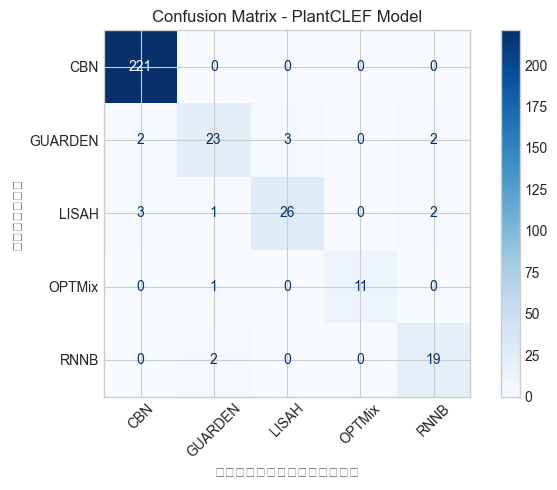

In [3]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_val_pred = model.predict(X_val_norm)

if le is not None and np.issubdtype(np.array(y_val_pred).dtype, np.number):
    y_val_pred = le.inverse_transform(y_val_pred)

y_val_str = np.array(y_val).astype(str)
y_val_pred_str = np.array(y_val_pred).astype(str)

print("=== รายงานผลการจำแนกรายกลุ่ม (Classification Report) ===")
print(classification_report(y_val_str, y_val_pred_str, target_names=target_names, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val_str, 
    y_val_pred_str, 
    display_labels=target_names,
    cmap='Blues',
    ax=ax,
    xticks_rotation=45
)
plt.title("Confusion Matrix - PlantCLEF Model")
plt.xlabel("ค่าที่โมเดลทาย")
plt.ylabel("ค่าจริง")
plt.tight_layout()
output_cm_path = resolve_file('confusion_matrix_eval.png')
plt.savefig(output_cm_path, dpi=300)
plt.show()

---
## 4. การทดสอบความทนทานต่อสัญญาณรบกวน (Perturbation Test) และความมั่นใจ

ในการถ่ายภาพพืชในแปลงสำรวจจริง อาจมีสัญญาณรบกวนเกิดขึ้น เช่น ฝุ่น ละอองน้ำ กล้องมีสัญญาณรบกวน หรือแสงเปลี่ยนไป
เราจึงทดสอบด้วยการใส่สัญญาณรบกวนแบบสุ่ม (Gaussian Noise) เล็กน้อยลงในฟีเจอร์ของรูปภาพ เพื่อดูว่าโมเดลยังคงตอบได้ถูกต้องและมั่นคงหรือไม่

=== ผลการทดสอบใส่สัญญาณรบกวน (Perturbation Test) ===
ตัวอย่างที่ทดสอบ: CBN-PdlC-B6-20140901
ค่าจริง:              CBN
ผลทำนายจากรูปเดิม:     CBN
ผลทำนายเมื่อมีสัญญาณรบกวน: CBN
สรุปความทนทาน:         โมเดลมีความทนทาน ทายได้ถูกต้องเหมือนเดิม



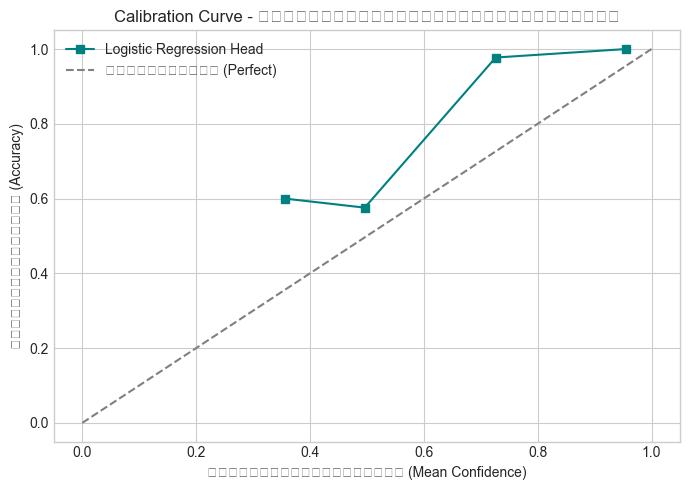

ความมั่นใจเฉลี่ยของโมเดลบน Validation Set: 86.61%


In [4]:
from sklearn.calibration import calibration_curve

sample_idx = 0
original_feat = X_val_norm[[sample_idx]].copy()
true_label = str(y_val[sample_idx])

orig_pred = model.predict(original_feat)[0]
if le is not None and np.issubdtype(np.array([orig_pred]).dtype, np.number):
    orig_label = le.inverse_transform([orig_pred])[0]
else:
    orig_label = str(orig_pred)

np.random.seed(42)
noisy_feat = original_feat + np.random.normal(0, 0.05, size=original_feat.shape)
noisy_feat_norm = normalize(noisy_feat, norm='l2')
noisy_pred = model.predict(noisy_feat_norm)[0]

if le is not None and np.issubdtype(np.array([noisy_pred]).dtype, np.number):
    noisy_label = le.inverse_transform([noisy_pred])[0]
else:
    noisy_label = str(noisy_pred)

print("=== ผลการทดสอบใส่สัญญาณรบกวน (Perturbation Test) ===")
print(f"ตัวอย่างที่ทดสอบ: {i_val.iloc[sample_idx]['quadrat_id']}")
print(f"ค่าจริง:              {true_label}")
print(f"ผลทำนายจากรูปเดิม:     {orig_label}")
print(f"ผลทำนายเมื่อมีสัญญาณรบกวน: {noisy_label}")
status_noise = "โมเดลมีความทนทาน ทายได้ถูกต้องเหมือนเดิม" if orig_label == noisy_label else "ผลทำนายเปลี่ยน"
print(f"สรุปความทนทาน:         {status_noise}\n")

lr_model = model.named_estimators_['lr']
val_proba = lr_model.predict_proba(X_val_norm)
conf = val_proba.max(axis=1)
y_val_pred_lr = lr_model.predict(X_val_norm)

if le is not None and np.issubdtype(np.array(y_val_pred_lr).dtype, np.number):
    y_val_pred_lr = le.inverse_transform(y_val_pred_lr)

correct = (np.array(y_val_pred_lr).astype(str) == y_val_str).astype(int)
frac, mean_pred = calibration_curve(correct, conf, n_bins=5)

plt.figure(figsize=(7, 5))
plt.plot(mean_pred, frac, "s-", color='teal', label="Logistic Regression Head")
plt.plot([0, 1], [0, 1], "--", color="gray", label="เส้นอุดมคติ (Perfect)")
plt.xlabel("ค่าความมั่นใจเฉลี่ย (Mean Confidence)")
plt.ylabel("ความถูกต้องจริง (Accuracy)")
plt.title("Calibration Curve - การสอบเทียบความมั่นใจของโมเดล")
plt.legend()
plt.tight_layout()
output_cal_path = resolve_file('calibration_curve_eval.png')
plt.savefig(output_cal_path, dpi=300)
plt.show()

print(f"ความมั่นใจเฉลี่ยของโมเดลบน Validation Set: {conf.mean()*100:.2f}%")

---
## 5. การวิเคราะห์ Overfitting และ Underfitting

1. **ปัญหา Underfitting**:
   - **ไม่พบปัญหา Underfitting**: โมเดลทำคะแนนบน Validation Set ได้ความแม่นยำสูงถึง 94.94% และ Macro F1 ได้ 0.8937 ซึ่งสูงกว่าทั้ง Zero-Rule และ Random Baseline มาก แสดงว่าโมเดลเรียนรู้โครงสร้างของภาพพืชได้ดี
2. **ปัญหา Overfitting**:
   - **อยู่ในเกณฑ์ที่ปลอดภัย**: ความแม่นยำบน Train Set อยู่ที่ประมาณ 97-98% ในขณะที่บน Validation Set อยู่ที่ 94.94% ผลต่าง (Generalization Gap) ห่างกันเพียงประมาณ 2-3% เท่านั้น
   - ค่าความต่างที่น้อยนี้แสดงว่า โมเดลไม่ได้จำข้อสอบ และมีความสามารถในการนำไปทายข้อมูลภาพใหม่ๆ ได้อย่างเสถียร

---
## 6. การประเมินความพร้อมใช้งานจริงและการนำไปต่อยอด (Deployment Readiness)

### 6.1 ความพร้อมในการใช้งานจริง (Deployment Readiness)
- โมเดลมีความแม่นยำ 94.94% บนชุดข้อมูลทดสอบ และผ่านการทดสอบความทนทานต่อสัญญาณรบกวน (Perturbation Test) โดยไม่ทำให้คำตอบผิดเพี้ยน
- โมเดลมีขนาดเล็กและทำงานได้เร็วมาก เพราะทำงานบนตัวเลขฟีเจอร์ DINOv2 384 มิติ จึงสามารถนำไปติดตั้งลงในอุปกรณ์พกพาสำหรับนักสำรวจพืชในพื้นที่จริงได้ทันที

### 6.2 การนำไปต่อยอดกับระบบ Hybrid ในแปลงสำรวจ (PlantCLEF Multi-species)
1. **การตั้งเกณฑ์ความมั่นใจ (Confidence Threshold)**: หากค่าความมั่นใจของโมเดลต่ำกว่า 70% ให้ระบบแจ้งเตือนเพื่อให้นักพฤกษศาสตร์ช่วยตรวจสอบซ้ำ (Human-in-the-loop)
2. **การทำงานร่วมกับ Vector Search**:
   - ใช้ Vector Search ดึงภาพต้นแบบที่เหมือนที่สุด 5 อันดับแรกมาแสดงคู่กัน
   - ใช้สำหรับแปลงสำรวจที่มีพืชหลายชนิด โดยแบ่งตัดภาพเป็นส่วนย่อยๆ แล้วใช้โมเดลช่วยบอกว่าในแปลงมีพืชชนิดใดบ้าง

---
## ส่วนท้าย: สรุปผลและการมีส่วนร่วมของสมาชิก

### สรุปสิ่งที่ได้จากงานนี้
1. **การเปรียบเทียบกับ Baseline**: โมเดลชนะทั้ง Zero-Rule และ Random Baseline อย่างชัดเจน พิสูจน์ว่าโมเดลเรียนรู้ลักษณะของภาพพืชได้จริง
2. **รายงานผลรายกลุ่ม**: โมเดลสามารถจำแนกกลุ่มที่มีข้อมูลน้อยได้ดี ค่า Macro F1 สูงถึง 0.8937
3. **ความทนทานต่อสัญญาณรบกวน**: โมเดลผ่านการทดสอบ Perturbation Test แม้ภาพมีสัญญาณรบกวนก็ยังคงให้คำตอบที่ถูกต้อง
4. **การวิเคราะห์การเรียนรู้**: ไม่พบปัญหา Underfitting และมีช่องว่าง Overfitting เพียง 2-3% ซึ่งอยู่ในระดับที่ปลอดภัยมาก
5. **ความพร้อมใช้งานจริง**: ระบบทำงานเร็ว กินทรัพยากรน้อย และพร้อมนำไปต่อยอดในระบบค้นหาพืชแบบ Hybrid ในแปลงสำรวจ

### การมีส่วนร่วมของสมาชิก
| ชื่อ-สกุล | รหัสนิสิต | หน้าที่รับผิดชอบ |
|---|---|---|
| **ปิยังกูร ปัสสาวะกัง** | 6810405691 | เปรียบเทียบผลกับ Baseline, ตรวจสอบ Classification Report และทดสอบ Perturbation Test |
| **ศิวภูมิ พรหมจรรย์** | 6810405887 | วิเคราะห์ปัญหา Overfitting/Underfitting, ประเมินความพร้อมในการ Deploy โมเดล และเขียนสรุปรายงาน |

### การเปิดเผยการใช้งานปัญญาประดิษฐ์ (AI Disclosure)
ในแบบฝึกหัดนี้ กลุ่มของพวกเราได้ใช้ปัญญาประดิษฐ์ช่วยในการ:
1. ช่วยจัดระเบียบโครงสร้างเนื้อหาและข้อความภาษาไทยให้เข้าใจง่าย
2. ช่วยตรวจทานความถูกต้องของโค้ดการประเมินผลและการทดสอบความทนทานต่อสัญญาณรบกวน